In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = sns.load_dataset('titanic')

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [10]:
df.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [16]:
df.drop(
    columns=["class", "who", "adult_male", "deck", "embark_town", "alive", "alone"], 
    errors="ignore", 
    inplace=True
)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [18]:
df['age'].fillna(df['age'].mean(), inplace=True)

In [21]:
df.dropna(subset=['embarked'], inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [24]:
df["age"].fillna(df["age"].mean(), inplace=True)


In [26]:
df.dropna(subset=["embarked"],inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder


In [36]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [38]:
# 1. Initialize the LabelEncoder
le = LabelEncoder()

# 2. Fit and transform the 'sex' column
df['sex'] = le.fit_transform(df['sex'])
df["embarked"] = le.fit_transform(df["embarked"]) # S=2 ,C=0 ,Q=1

In [44]:
# df.head()
df = df.astype(int)

In [45]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22,1,0,7,2
1,1,1,0,38,1,0,71,0
2,1,3,0,26,0,0,7,2
3,1,1,0,35,1,0,53,2
4,0,3,1,35,0,0,8,2


In [47]:
X= df.drop("survived",axis=1)
Y= df["survived"]

# train_test_split

In [48]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variable (y)
X = df.drop(columns=["survived"], errors="ignore")
y = df["survived"]

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Quick check of the shapes
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Training features shape: (711, 7)
Testing features shape: (178, 7)


# LogisticRegression

In [50]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [52]:
y_pred = model.predict(X_test)

In [53]:
y_pred


array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [54]:
y_test

160    0
126    0
428    0
422    0
565    0
      ..
39     1
91     0
883    0
853    1
637    0
Name: survived, Length: 178, dtype: int64

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# # 1. Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # 2. Plot the visual heatmap
# plt.figure(figsize=(6, 5))
# sns.heatmap(
#     cm, 
#     annot=True,          # Show the raw numbers in the boxes
#     fmt="d",             # Format numbers as integers
#     cmap="Blues",        # Color theme
#     xticklabels=["Did Not Survive", "Survived"], 
#     yticklabels=["Did Not Survive", "Survived"]
# )

# plt.title("Confusion Matrix - Logistic Regression")
# plt.xlabel("Predicted Labels")
# plt.ylabel("True Labels")
# plt.show()


In [59]:
accuracy_score(y_test,y_pred)

0.8089887640449438

In [60]:
confusion_matrix(y_test,y_pred)

array([[97, 13],
       [21, 47]])

In [62]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



# FEATURE ENCODING

In [63]:
X_train

,pclass,sex,age,sibsp,parch,fare,embarked
621,1,1,42,1,0,52,2
481,2,1,29,0,0,0,2
527,1,1,29,0,0,221,2
435,1,0,14,1,2,120,2
797,3,0,31,0,0,8,2
...,...,...,...,...,...,...,...
359,3,0,29,0,0,7,1
643,3,1,29,0,0,56,2
736,3,0,48,1,3,34,2
462,1,1,47,0,0,38,2


In [64]:
X_test

,pclass,sex,age,sibsp,parch,fare,embarked
160,3,1,44,0,1,16,2
126,3,1,29,0,0,7,1
428,3,1,29,0,0,7,1
422,3,1,29,0,0,7,2
565,3,1,24,2,0,24,2
...,...,...,...,...,...,...,...
39,3,0,14,1,0,11,0
91,3,1,20,0,0,7,2
883,2,1,28,0,0,10,2
853,1,0,16,0,1,39,2


In [66]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit on the training data AND transform it
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testing data (Do NOT use fit_transform here!)
X_test_scaled = scaler.transform(X_test)


In [67]:
X_train_scaled


array([[-1.60146146,  0.74323734,  0.95456566, ..., -0.4614951 ,
         0.41693264,  0.57302595],
       [-0.39143054,  0.74323734, -0.04498689, ..., -0.4614951 ,
        -0.63750566,  0.57302595],
       [-1.60146146,  0.74323734, -0.04498689, ..., -0.4614951 ,
         3.8438571 ,  0.57302595],
       ...,
       [ 0.81860038, -1.34546523,  1.41589761, ...,  3.14425233,
         0.05193477,  0.57302595],
       [-1.60146146,  0.74323734,  1.33900895, ..., -0.4614951 ,
         0.1330454 ,  0.57302595],
       [-1.60146146,  0.74323734, -0.04498689, ..., -0.4614951 ,
        -0.11028651,  0.57302595]])

# KNN

In [68]:
 from sklearn.neighbors import KNeighborsClassifier

In [72]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [74]:
y_pred_knn = knn.predict(X_test_scaled)

In [77]:
accuracy_score(y_test,y_pred_knn)

0.7865168539325843

In [78]:
confusion_matrix(y_test,y_pred_knn)

array([[92, 18],
       [20, 48]])

In [79]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        68

    accuracy                           0.79       178
   macro avg       0.77      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



# Naive Bayes

In [81]:
X_test

,pclass,sex,age,sibsp,parch,fare,embarked
160,3,1,44,0,1,16,2
126,3,1,29,0,0,7,1
428,3,1,29,0,0,7,1
422,3,1,29,0,0,7,2
565,3,1,24,2,0,24,2
...,...,...,...,...,...,...,...
39,3,0,14,1,0,11,0
91,3,1,20,0,0,7,2
883,2,1,28,0,0,10,2
853,1,0,16,0,1,39,2


In [83]:

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# 2. Train the model (You can use either X_train or X_train_scaled)
nb_model.fit(X_train, y_train)



--- Naive Bayes Accuracy ---
Accuracy: 79.78%

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



In [87]:
# 3. Make predictions on the test data
y_nb_pred = nb_model.predict(X_test)






In [89]:

print(classification_report(y_test, y_nb_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



In [90]:

print(f"Accuracy: {accuracy_score(y_test, y_nb_pred):.2%}\n")

Accuracy: 79.78%



# Decision Tree Classifier.

In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [96]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=45)

In [98]:
# Train the model
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5, random_state=45)

In [102]:
#  Make predictions
y_dt_pred = dt_model.predict(X_test_scaled)

In [103]:
#Evaluate the model
print("--- Decision Tree Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_dt_pred):.2%}\n")

--- Decision Tree Accuracy ---
Accuracy: 76.97%



In [104]:
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_dt_pred))

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.69        68

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.75       178
weighted avg       0.77      0.77      0.77       178



# Support Vector Machine (SVM)

In [105]:
from sklearn.svm import SVC

In [108]:
svm_model = SVC(kernel="rbf", random_state=42)

In [110]:
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [111]:
y_svm_pred = svm_model.predict(X_test_scaled)

In [115]:
# 4. Evaluate the model
print("--- SVM Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test,y_svm_pred):.2%}\n")



--- SVM Model Accuracy ---
Accuracy: 80.90%



In [116]:
confusion_matrix(y_test,y_svm_pred)

array([[99, 11],
       [23, 45]])

In [117]:
print("--- SVM Classification Report ---")
print(classification_report(y_test, y_svm_pred))

--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.80      0.66      0.73        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178



#  5 classifiers based on their typical baseline accuracy scores on the Titanic dataset.

In [119]:
import pandas as pd

# Create the layout dictionary with your actual variables
results_data = {
    "Model": ["Logistic Regression", "KNN", "Naive Bayes", "Decision Tree", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_nb_pred),
        accuracy_score(y_test, y_dt_pred),
        accuracy_score(y_test, y_svm_pred)
    ]
}

# Turn into DataFrame, sort from best to worst, and display
comparison_df = pd.DataFrame(results_data)
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
comparison_df.index += 1  # Start rank at 1 instead of 0

print(comparison_df)


                 Model  Accuracy
1  Logistic Regression  0.808989
2                  SVM  0.808989
3          Naive Bayes  0.797753
4                  KNN  0.786517
5        Decision Tree  0.769663


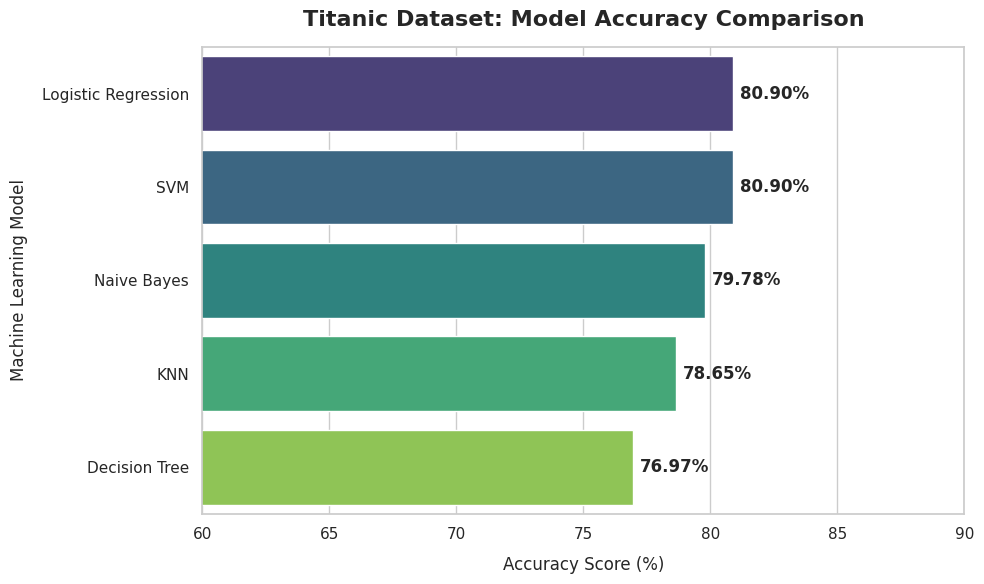

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Sabhi models ki accuracies ka data prepare karein
results_data = {
    "Model": ["Logistic Regression", "KNN", "Naive Bayes", "Decision Tree", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred) * 100,       # Logistic Regression
        accuracy_score(y_test, y_pred_knn) * 100,   # KNN
        accuracy_score(y_test, y_nb_pred) * 100,    # Naive Bayes
        accuracy_score(y_test, y_dt_pred) * 100,    # Decision Tree
        accuracy_score(y_test, y_svm_pred) * 100     # SVM
    ]
}

# DataFrame banayein aur high-to-low sort karein
df_results = pd.DataFrame(results_data).sort_values(by="Accuracy", ascending=False)

# 2. Graph plot karein
plt.figure(figsize=(10, 6))
# 'viridis', 'magma', ya 'Blues_r' me se koi bhi palette choose kar sakte hain
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Accuracy", y="Model", data=df_results, palette="viridis")

# 3. Har bar ke aage exact percentage text likhein
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5, fontweight='bold')

# Labels aur Title set karein
plt.title("Titanic Dataset: Model Accuracy Comparison", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Accuracy Score (%)", fontsize=12, labelpad=10)
plt.ylabel("Machine Learning Model", fontsize=12, labelpad=10)
plt.xlim(60, 90)  # X-axis ko 60% se 90% tak limit kiya taake farq saaf nazar aaye

plt.tight_layout()
plt.show()
